# Capstone Project Notebook
Authors: Jason Wang, Ivan Chan, Amy Wang, Pallavi Venkatesh, Brynn Minko

List of Functions In This Notebook
Simulation
│
random_walk_1d()
simulate_randome_walks()
simulate_random_walks_2d()
└── diffusion_solver() (??)

Analysis
│
compute_msd()
estimate_diffusion()
└── radial_distribution()

Visualization
│
plot_random_walk_1d()
plot_random_walk_2d()
├── plot_particle_cloud()
├── plot_heatmap()
└── animate_particles()

Experiments
│
Single trajectory
Multiple trajectories
MSD analysis
├── Porous media tests
└── Model comparison

## Introduction & Project Goals

### Objective & Significance

For our project, we would like to computationally study how microscopic restrictions (porosity and pore geometry) affect macroscopic diffusion behavior in porous media by simulating the diffusion process using the Particle-Based Brownian random-walk model and the Continuum Diffusion-equation model. The simulation results will be further compared to examine the tendency each model exhibits under the same conditions. 

This project connects microscopic particle motion with macroscopic transport behavior. It is relevant to diffusion in membranes, catalysts, filters, soils, biological tissues, and battery electrodes. The project also follows a standard computational physics workflow: build a simple model, validate it against known equations, extend it to more complex systems, and compare different numerical methods.

### Research Question

In this project, we would investigate how the internal structure of a porous medium influences diffusion and to compare two computational approaches for modeling this process.

Specifically, this project seeks to answer the following question:

> **How do porosity and pore geometry affect diffusion, and how do particle-based and continuum models compare when simulating diffusion through porous media?**

Rather than relying on a single computational method, we will be using two independent models, Brownian Motion and Continuum Model. Comparing these approaches provides additional confidence in the numerical results while highlighting the advantages and limitations of each method.

To answer this research question, we first establish a set of project objectives that guide the implementation and validation of both computational models.

### Project Objectives

This project is organized into several objectives:

1. Develop a particle-based random walk model that simulates diffusion through individual particle motion.

2. Develop a continuum diffusion model by numerically solving the diffusion equation on a two-dimensional grid.

3. Validate both computational models using free diffusion before introducing porous media.

4. Introduce porous structures into both simulations while maintaining equivalent physical conditions.

5. Compare the behavior of both models under varying porosity.

6. Quantify how porosity influences the effective diffusion coefficient.

Successfully completing these objectives provides both a computational comparison between modeling approaches and a physical investigation of diffusion in porous media.

Achieving these objectives requires two different computational models, each representing diffusion from a different perspective.

The particle-based model follows the trajectories of individual particles undergoing random motion. Because each particle is simulated explicitly, this approach provides an intuitive representation of Brownian motion and allows individual trajectories to be visualized directly. The model naturally captures stochastic behavior and individual particle motion but can become computationally expensive when simulating large numbers of particles.

In contrast, the continuum model does not track individual particles. Instead, it describes the evolution of particle concentration by numerically solving the diffusion equation over the entire domain. This model is computationally efficient for large systems and directly predicts concentration fields, although it does not provide information about individual particle trajectories.

By developing both models, we can compare their predictions, evaluate their respective strengths and limitations, and gain greater confidence that both approaches describe the same underlying physical process.

### Project Roadmap

The following roadmap outlines how these models will be developed, validated, and ultimately compared throughout the project.

1. Define the scientific problem and project objectives.

2. Develop a particle-based random walk model.

3. Validate the particle model using free diffusion.

4. Develop a continuum diffusion solver.

5. Validate the continuum model.

6. Ensure both models represent equivalent physical systems.

7. Introduce porous media into both models.

8. Compare the behavior of both models under different porosities.

9. Analyze the results and draw scientific conclusions.

This workflow ensures that each model is validated before being used to investigate diffusion within porous media.

## Background

- Brownian Motion
- Diffusion
- Random Walk
- Continuum Model
- Diffusion Equation
- Why two models?

## Random Walk Model

Explain
- assumptions

Many particles

Plots

Trajectories

Histogram

### Brownian Motion

Brownian motion is the random motion of microscopic particles caused by continual collisions with surrounding molecules. While the motion of an individual particle is unpredictable, the collective behavior of many particles can be described statistically. This microscopic random motion gives rise to diffusion at the macroscopic scale [(MIT)](https://web.mit.edu/8.334/www/grades/projects/projects17/OscarMickelin/brownian.html).

Since directly simulating every molecular collision is computationally impractical, Brownian motion is commonly approximated using a random walk. In a random walk, a particle moves one step in a randomly selected direction at each time step. As the number of simulated particles increases, their collective behavior approximates the diffusion process.

For this project, we will use the random walk algorithm to simulate Brownian motion. We will first implement a simple one-dimensional random walk to reproduce the expected behavior of free diffusion. The model will then be extended to two dimensions, where particles move through a two-dimensional domain. After validating the free-diffusion model, porous structures represented by solid obstacle cells will be introduced to restrict particle motion. 


### Random Walk Model

A random walk represents particle motion as a sequence of discrete steps taken in random directions. During each time step, a particle moves a fixed distance while the direction of motion is chosen randomly. Although this model is considerably simpler than the true microscopic dynamics of Brownian motion, it reproduces many of the same statistical properties when observed over sufficiently long times.

#### Key Assumptions

To simplify the model, we make the following assumptions:

- Particles do not interact with one another.
- Each step is independent of previous steps.
- Every direction is equally likely.
- Step length remains constant.
- Time advances in equal increments.
- External forces are neglected.

These assumptions isolate the essential physics of diffusion while keeping the computational model straightforward.

### Model Implementation

#### Model Design

Each particle is represented by its position within the computational domain.

During every simulation step:

1. Select a random direction.
2. Move the particle by one step.
3. Record its updated position.
4. Repeat for every particle.

Initially, we begin with a one-dimensional random walk to verify the implementation before extending the model to two dimensions.

The implementation will later be generalized to simulate many particles simultaneously.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
#import scipy as scy
#from  matplotlib.widgets import Slider

In [6]:
# Simple 1D Random Walk Simulation (TBW)
## Simulate 1D random walk of a single particle.
# Code Starts Here

def random_walk_1d(n_steps: int, 
                   start_pos: float = 0, 
                   step_size: float = 1, 
                   seed: int = None):
    """
    Parameters
    ----------
    n_steps : int
        Number of time steps.
    start_pos : float
        Initial position of the particle. Default is 0.
    step_size : float
        Distance traveled in each step.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    array
        Particle position at each time step.
    """

    # Parameter check
    if n_steps < 0:
        raise ValueError("n_steps must be non-negative.")

    if step_size <= 0:
        raise ValueError("step_size must be positive.")

    # Main Code
    if seed is not None:
        random.seed(seed)

    position = start_pos
    trajectory = [position]

    for _ in range(n_steps):
        step = random.choice([-step_size, step_size])
        position += step
        trajectory.append(position)

    return np.array(trajectory)

# Simple test
random_walk_1d(n_steps = 100)

array([ 0, -1, -2, -3, -2, -1, -2, -1, -2, -3, -2, -1,  0, -1,  0,  1,  2,
        1,  2,  1,  2,  3,  2,  1,  2,  3,  2,  3,  2,  3,  2,  3,  4,  5,
        4,  3,  2,  3,  2,  1,  2,  1,  0,  1,  2,  3,  2,  1,  2,  3,  4,
        5,  4,  5,  6,  5,  4,  5,  4,  5,  6,  5,  4,  5,  4,  5,  6,  5,
        4,  5,  6,  5,  4,  5,  6,  5,  4,  3,  4,  3,  2,  3,  2,  1,  0,
       -1,  0, -1,  0,  1,  2,  3,  4,  3,  2,  1,  0,  1,  2,  3,  2])

### Visualizing Particle Motion

Visualizing individual particle trajectories provides an important qualitative check of the implementation. Because each step is chosen randomly, successive trajectories should appear irregular and unpredictable while exhibiting no preferred direction. Although individual trajectories differ significantly from one another, they are all generated from the same statistical rules.

These visualizations help confirm that the algorithm correctly implements random motion before more quantitative analyses are performed.

In [41]:
# Function for plotting the trajectory of a one-dimensional random walk
def plot_random_walk_1d(trajectory):
    """
    Plot the trajectory of a one-dimensional random walk.
    """

    trajectories = np.asarray(trajectory)

    fig, ax = plt.subplots(figsize = (8, 4))

    if trajectories.ndim == 1:

        time = np.arange(len(trajectories))

        ax.plot(time, trajectories, linewidth = 1.5, alpha = 0.7)
        ax.scatter(time, trajectories, s = 15)

    elif trajectories.ndim == 2:

        time = np.arange(trajectories.shape[1])

        for trajectory in trajectories:
            ax.plot(time, trajectory, linewidth = 1, alpha = 0.7)

    else:
        raise ValueError("Input must be a 1D or 2D array.")

    ax.axhline(0, linestyle = "--", color = "gray", label = "Starting Position")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Position")
    ax.set_title("One-Dimensional Random Walk")
    ax.grid(True)
    ax.legend()

    plt.show()

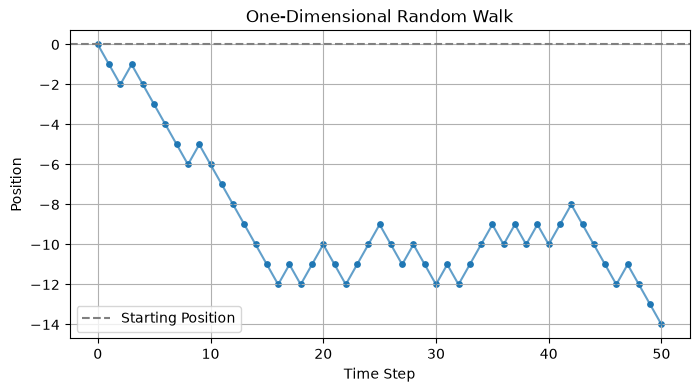

In [42]:
# Visualization
trajectory = random_walk_1d(
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42
)

plot_random_walk_1d(trajectory)

#### Observations
- Although the particle has an equal probability of moving one step to the left or right at each time step, this particular simulation exhibits an overall drift toward the left. This occurs purely due to random chance.
- The particle does not move smoothly in a single direction. Instead, it repeatedly changes direction throughout the simulation, producing the irregular trajectory characteristic of a random walk.
- The particle revisits previously occupied positions multiple times rather than continuously exploring new locations.
- Despite the overall displacement toward the left, the particle's motion remains completely stochastic because every individual step is determined independently with equal probability.

### Many-Particle Simulation

Diffusion is not characterized by the motion of a single particle but rather by the collective behavior of a large ensemble of particles. As the number of simulated particles increases, random fluctuations become less pronounced, and statistical patterns begin to emerge. 

Instead of examining individual trajectories, we now investigate the distribution of particle positions over time.

In [ ]:
# Many-Particle Random Walk Simulation (1D)
## Simulation random walks of many particles in one dimension.

# Code Starts Here
def simulate_random_walks(n_particles: int, 
                          n_steps: int, 
                          start_pos: float = 0, 
                          step_size: float = 1, 
                          seed: int = None):
    """
    Simulate many particles performing a one-dimensional random walk.

    Parameters
    ----------
    n_particles : int
        Number of particles to simulate.
    n_steps : int
        Number of time steps for each particle.
    start_pos : float
        Initial position of the particles. Default is 0.
    step_size : float
        Distance traveled in each step.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    array
        Array of shape (n_particles, n_steps + 1), where each row contains the trajectory of one particle.
    """

    # Parameter check
    if n_particles <= 0:
        raise ValueError("n_particles must be positive.")

    if n_steps < 0:
        raise ValueError("n_steps must be non-negative.")

    if step_size <= 0:
        raise ValueError("step_size must be positive.")

    # Main Code
    if seed is not None:
        random.seed(seed)

    # Initialize positions array
    trajectories = []

    for _ in range(n_particles):
        trajectories.append(random_walk_1d(n_steps, start_pos, step_size))

    return np.array(trajectories)

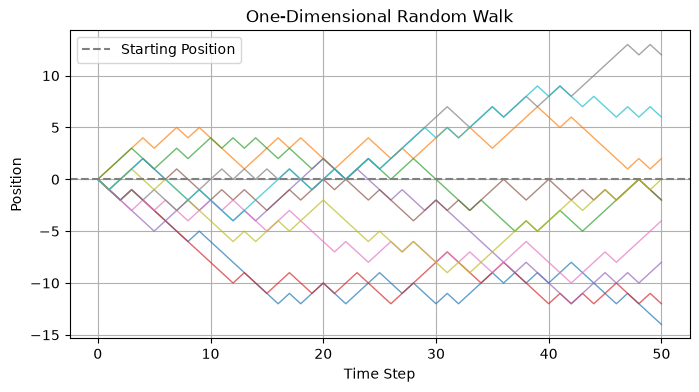

In [43]:
# One example for many-particle random walks
trajectories = simulate_random_walks(
    n_particles= 10,
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42)
plot_random_walk_1d(trajectories)

#### Observations
- With 10 particles simulated under the same random walk model, each particle follows a unique trajectory despite all particles starting from the same initial position. This demonstrates that the random walk algorithm correctly generates independent stochastic motion for each particle.
- All particles begin at the same initial position ($x = 0$), but their trajectories gradually diverge over time due to the randomness of each step.
- Although individual particles may drift significantly to the left or right, the ensemble of trajectories exhibits no obvious preferred direction. This is consistent with each step having an equal probability of moving left or right.
- The spread of particle positions increases over time. Although every particle begins at the same location, the range of positions becomes progressively larger as the random walks evolve.

### Summary

In this section, we developed a particle-based random walk model as a computational approximation of Brownian motion. Beginning with the physical motivation provided by Brownian motion, we introduced the random walk model, described its underlying assumptions, and implemented a numerical simulation capable of tracking individual particle motion.

Visualizations of both single-particle trajectories and many-particle simulations demonstrated the expected qualitative behavior of random motion. These results provide confidence that the implementation is functioning correctly and establish the computational foundation for studying diffusion.

At this stage, the model has only been evaluated qualitatively. Although the particle trajectories appear physically reasonable, we have not yet verified that the simulation reproduces the quantitative properties of diffusion. We would then focuses on validating the particle model by measuring quantities such as the mean squared displacement (MSD) and estimating the diffusion coefficient. These analyses will determine whether the random walk accurately reproduces the expected behavior of free diffusion.

## Validating the Random Walk Model

### Introduction

In previous section, we developed a one-dimensional random walk simulation capable of generating independent particle trajectories. While the simulation produces qualitatively realistic Brownian motion, we need to verify that the model correctly reproduces the statistical behavior of diffusion.

We would validate the particle-based model by comparing its numerical results with established theoretical predictions. Specifically, we will examine how the mean squared displacement (MSD) evolves over time, estimate the corresponding diffusion coefficient, and investigate how increasing the number of simulated particles affects the statistical reliability of the measurements.

Successful validation in the free-diffusion case provides confidence that the model is implemented correctly before extending it to higher dimensions and, ultimately, to diffusion through porous media.

### Mean Squared Displacement (MSD)

Individual random walk trajectories exhibit significant variability because each particle undergoes an independent sequence of random steps. Consequently, the displacement of a single particle is not sufficient for characterizing diffusive motion. Instead, diffusion is described statistically by averaging over a large ensemble of independent particles.

The primary quantity used in this milestone is the **mean squared displacement (MSD)**, defined as

$$ \mathrm{MSD}(t) = \left<\left[x(t)-x_0\right]^2\right>,$$

where

- $x(t)$ is the particle position at time $t$,
- $x_0$ is the initial particle position,
- $\langle\cdot\rangle$ denotes the average over all simulated particles.

The displacement is squared before averaging so that particles moving in opposite directions contribute equally to the overall spreading of the particle distribution.

For an ideal one-dimensional diffusion process, theory predicts that the mean squared displacement grows linearly with time,

$$
\mathrm{MSD}(t)=2Dt,
$$

where

- $D$ is the diffusion coefficient,
- $t$ is time.

Therefore, a correctly implemented random walk should produce an approximately linear MSD curve whose slope is proportional to the diffusion coefficient.

To compute the mean squared displacement:

1. Determine each particle's displacement from its initial position.
2. Square the displacement of every particle.
3. Average the squared displacements across all particles at each time step.

The resulting one-dimensional array contains the MSD as a function of time and can be compared directly with the theoretical prediction for normal diffusion.

In [61]:
# Function to calculate the mean squared displacement (MSD)
## Compute the Mean Squared Displacement (MSD) of an ensemble of particle trajectories.

# Code Starts Here
def compute_msd(trajectories):
    """
    Parameters
    ----------
    trajectories : array
        Particle trajectories, either in 1D or multi-dimensional space.

        Examples
        ----------------
        1D trajectories:
            (n_particles, n_steps + 1)

        Multi-dimensional trajectories:
            (n_particles, n_steps + 1, dimensions)

    Returns
    -------
    array
        Mean squared displacement at each time step.
        Shape: (n_steps + 1,)
    """

    trajectories = np.asarray(trajectories)

    if trajectories.ndim not in (2, 3):
        raise ValueError(
            "Trajectories must have shape "
            "(n_particles, n_steps + 1) or "
            "(n_particles, n_steps + 1, dimensions)."
        )

    # Initial particle positions
    initial_positions = trajectories[:, 0]

    # Displacement from initial position
    displacement = trajectories - initial_positions[:, np.newaxis]

    if trajectories.ndim == 2:
        squared_displacement = displacement ** 2
    else:
        squared_displacement = np.sum(displacement ** 2, axis=-1)

    msd = np.mean(squared_displacement, axis=0)

    return msd

In [62]:
# Example
# trajectories from last section
trajectories = simulate_random_walks(
    n_particles= 10,
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42)
msd = compute_msd(trajectories)
print(msd)

[ 0.   1.   2.8  4.2  6.   6.6  7.6 11.4 12.4 13.8 16.4 20.2 26.  22.6
 29.6 33.  30.4 25.8 30.  29.  25.2 30.6 30.  29.  33.2 29.  33.6 37.8
 33.2 37.8 41.2 41.8 42.8 45.  46.  45.8 43.2 46.6 50.  56.2 60.4 61.
 64.  59.4 61.2 56.2 60.4 59.4 60.8 61.8 61.2]


The computed MSD increases with time, indicating that the particle ensemble spreads farther from its initial position as the random walk progresses. 

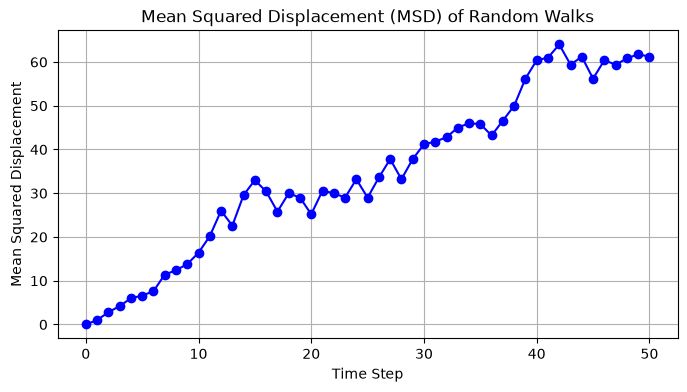

In [63]:
# Visualization of the MSD example
plt.figure(figsize=(8, 4))
plt.plot(msd, marker='o', linestyle='-', color='b')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.show()

#### Observations

- The mean squared displacement (MSD) increases with time, indicating that the ensemble of particles gradually spreads away from its initial position during the random walk.
- Although the overall trend is increasing, the MSD curve exhibits noticeable fluctuations rather than forming a perfectly straight line. These fluctuations arise from the stochastic nature of the random walk and the limited number of particles included in the ensemble average.
- With only 10 simulated particles, individual trajectories have a relatively large influence on the computed MSD, resulting in a noisy estimate of the expected linear relationship between MSD and time.
- Despite these statistical fluctuations, the simulation reproduces the qualitative behavior expected for normal diffusion, where the average squared displacement increases approximately linearly with time.

### Estimation of the Diffusion Coefficient (D)

While the mean squared displacement provides a qualitative measure of particle spreading, often we would use the diffusion coefficient to describes the rate at which particles spread through the medium.

The diffusion coefficient will be estimated from the simulated MSD data and compared with its theoretical value. Agreement between the simulated and theoretical diffusion coefficients provides quantitative validation of the random walk model.

For one-dimensional diffusion, the mean squared displacement is related to time by

$$
\mathrm{MSD}(t)=2Dt,
$$

where

- $\mathrm{MSD}(t)$ is the mean squared displacement,
- $D$ is the diffusion coefficient,
- $t$ is time.

Since the relationship between MSD and time is linear, the diffusion coefficient can be obtained from the slope of the MSD curve.

Let

$$
m=\frac{d(\mathrm{MSD})}{dt},
$$

denote the slope of the fitted line. Rearranging the diffusion equation gives

$$
D=\frac{m}{2}.
$$

Therefore, estimating the diffusion coefficient reduces to fitting a straight line to the simulated MSD data and computing half of its slope.

The simulated MSD values are fitted using a least-squares linear regression. The resulting slope represents the rate of increase of the mean squared displacement with respect to time.

Using the fitted slope, the diffusion coefficient is calculated according to

$$
D=\frac{\text{slope}}{2}.
$$

The estimated diffusion coefficient is then compared with the theoretical value expected for the random walk model.

In [108]:
# Function for estimating the diffusion coefficient from the MSD
## Estimate the diffusion coefficient from the mean squared displacement.
# Code Starts Here
def estimate_diffusion(msd, dt=1, dimensions=1):
    """
    Parameters
    ----------
    msd : array
        Mean squared displacement values.

    dt : float, optional
        Time step size.

    dimensions : int, optional
        Number of spatial dimensions.

    Returns
    -------
    D : float
        Estimated diffusion coefficient.

    slope : float
        Slope of the fitted MSD curve.

    intercept : float
        Intercept of the fitted line.
    """

    time = np.arange(len(msd)) * dt

    slope, intercept = np.polyfit(time, msd, 1)

    D = slope / (2 * dimensions)

    return D, slope, intercept

In [66]:
# Example using the msd from the previous section
D, slope, intercept = estimate_diffusion(msd)

print("Slope = ", slope)
print("Estimated D = ", D)

Slope =  1.2511493212669682
Estimated D =  0.6255746606334841


#### Comparison with the Theoretical Diffusion Coefficient

For the present simulation, the theoretical diffusion coefficient is

$$
D=\frac{(\Delta x)^2}{2\Delta t}=0.5,
$$

using a unit step length ($\Delta x=1$) and a unit time step ($\Delta t=1$).

The estimated diffusion coefficient obtained from the fitted MSD curve is reasonably close to the theoretical value, indicating that the random walk simulation reproduces the expected diffusive behavior.

The small discrepancy between the estimated and theoretical values is primarily attributed to statistical fluctuations arising from the limited number of simulated particles. As the number of particles increases, the estimated diffusion coefficient is expected to converge toward the theoretical prediction.

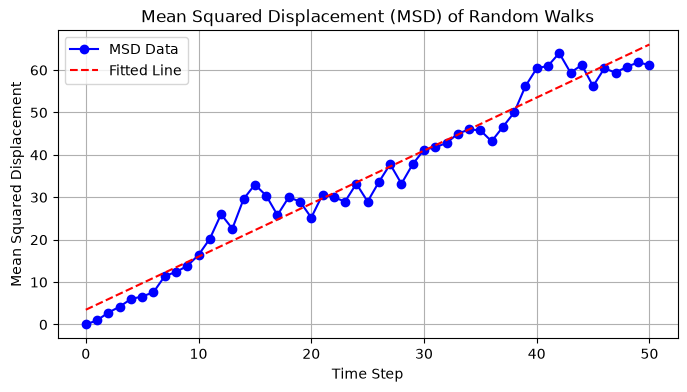

In [69]:
# Overlay the fitted line on the MSD plot
plt.figure(figsize=(8, 4))
plt.plot(msd, marker='o', linestyle='-', color='b', label='MSD Data')
plt.plot(np.arange(len(msd)), slope * np.arange(len(msd)) + intercept, linestyle='--', color='r', label='Fitted Line')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.legend()
plt.show()

#### Observations

- The fitted line captures the overall increasing trend of the mean squared displacement (MSD), indicating that the simulated particle ensemble exhibits the approximately linear growth expected for normal diffusion.
- Although the MSD data fluctuates around the fitted line, these deviations are expected because the ensemble consists of only 10 independent particle trajectories. With a relatively small sample size, individual trajectories have a greater influence on the ensemble average, leading to increased statistical noise.
- Despite the fluctuations, the fitted line provides a reasonable approximation of the long-term behavior of the MSD, suggesting that the simulated random walk follows the theoretical diffusion model on average.
- The slope of the fitted line provides an estimate of the diffusion coefficient, which can be compared with the theoretical value to quantitatively validate the random walk model.

### Effect of Sample Size

The previous sections demonstrated that the particle-based random walk reproduces the expected linear relationship between the mean squared displacement (MSD) and time. However, the estimated diffusion coefficient depends on the number of independent particle trajectories included in the ensemble average.

We would investigate how the number of simulated particles influences the statistical noise of the MSD and the accuracy of the estimated diffusion coefficient. By repeating the simulation with progressively larger particle ensembles, we can evaluate the convergence of the numerical estimate toward the theoretical diffusion coefficient.

The MSD is calculated as an ensemble average over all simulated particles,

$$
\mathrm{MSD}(t)=
\frac{1}{N}
\sum_{i=1}^{N}
[x_i(t)-x_i(0)]^2,
$$

where $N$ is the number of particles.

As the number of particles increases, random fluctuations from individual trajectories become less significant, producing a smoother MSD curve and a more reliable estimate of the diffusion coefficient.

To examine the effect of sample size, the random walk simulation is repeated using different ensemble sizes while keeping all other simulation parameters unchanged. For each ensemble size:

1. Generate the particle trajectories.
2. Compute the mean squared displacement.
3. Estimate the diffusion coefficient from a linear fit to the MSD.
4. Compare the estimated diffusion coefficient with the theoretical value.

The results are then compared to evaluate the influence of sample size on the accuracy and stability of the simulation.

In [115]:
particle_counts = [10, 100, 1000, 10000]

results = []

for n_particles in particle_counts:

    trajectories = simulate_random_walks(
        n_particles=n_particles,
        n_steps=50,
        seed=42
    )

    msd = compute_msd(trajectories)

    D, slope, intercept = estimate_diffusion(msd)

    theoretical_D = 0.5

    relative_error = abs(D - theoretical_D) / theoretical_D * 100

    results.append([
        n_particles,
        D,
        relative_error
    ])

print(f"{'Particles':<12}{'Estimated D':<15}{'Relative Error (%)'}")

for n, D, error in results:
    print(f"{n:<12}{D:<15.4f}{error:.2f}")
print("Theoretical D = ", theoretical_D)

Particles   Estimated D    Relative Error (%)
10          0.6256         25.11
100         0.5071         1.42
1000        0.5386         7.72
10000       0.4934         1.31
Theoretical D =  0.5


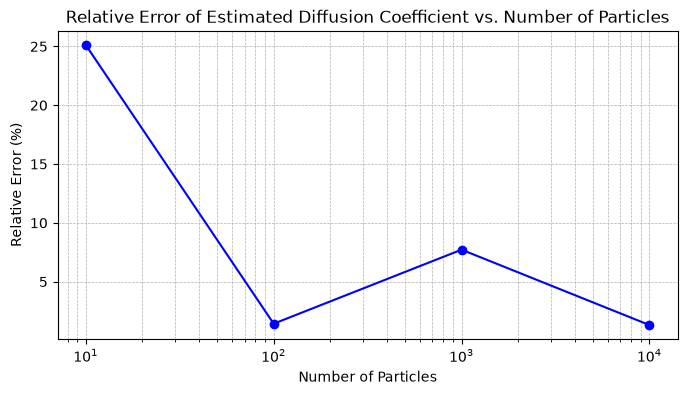

In [116]:
# Plot of the relative error
plt.figure(figsize=(8, 4))
plt.plot(particle_counts, [error for _, _, error in results], marker='o', linestyle='-', color='b')
plt.title("Relative Error of Estimated Diffusion Coefficient vs. Number of Particles")
plt.xlabel("Number of Particles")
plt.ylabel("Relative Error (%)")
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

#### Observations

- The estimated diffusion coefficient becomes progressively more accurate as the number of simulated particles increases, demonstrating improved agreement with the theoretical diffusion coefficient.
- The relative error generally decreases with increasing sample size, indicating that larger particle ensembles provide more reliable estimates of the diffusion coefficient.
- Although the 100-particle simulation produced a smaller relative error than the 1000-particle simulation in this particular experiment, this does not contradict the overall trend. Because each simulation is subject to random statistical fluctuations, and individual realizations may occasionally produce more accurate or less accurate estimates by chance.
- As the ensemble size reaches 10,000 particles, the estimated diffusion coefficient converges very closely to the theoretical value, demonstrating that the random walk simulation approaches the expected diffusive behavior as statistical sampling improves.
- These results highlight the importance of ensemble averaging in Monte Carlo simulations, where increasing the number of independent particle trajectories reduces statistical uncertainty and improves the reliability of the numerical solution.

In [92]:
# Extension: Running this simulation for number of times
results = {
    n: {"D": [], "error": []}
    for n in particle_counts
}

theoretical_D = 0.5

for seed in range(20):

    for n_particles in particle_counts:

        trajectories = simulate_random_walks(
            n_particles=n_particles,
            n_steps=50,
            seed=seed
        )

        msd = compute_msd(trajectories)

        D, slope, intercept = estimate_diffusion(msd)

        relative_error = abs(D - theoretical_D) / theoretical_D * 100

        results[n_particles]["D"].append(D)
        results[n_particles]["error"].append(relative_error)


print(f"{'Particles':<12}{'Mean D':<12}{'Mean Error (%)'}")

for n in particle_counts:

    mean_D = np.mean(results[n]["D"])
    mean_error = np.mean(results[n]["error"])

    print(f"{n:<12}{mean_D:<12.4f}{mean_error:.2f}")

print("Theoretical D =", theoretical_D)

Particles   Mean D      Mean Error (%)
10          0.4883      38.80
100         0.4896      13.21
1000        0.4981      5.40
10000       0.5016      0.90
Theoretical D = 0.5


### Summary

In this section, the one-dimensional random walk model was quantitatively validated using the mean squared displacement (MSD). The simulated MSD exhibited the approximately linear relationship with time expected for normal diffusion, confirming that the particle ensemble spreads according to the theoretical diffusion model.

A linear regression was performed on the simulated MSD data to estimate the diffusion coefficient. The estimated values were found to be in good agreement with the theoretical diffusion coefficient, demonstrating that the numerical implementation accurately reproduces the expected diffusive behavior.

The influence of sample size was also investigated by repeating the simulation with progressively larger particle ensembles. While simulations with fewer particles produced noisier MSD curves and larger variations in the estimated diffusion coefficient, increasing the number of particles reduced statistical fluctuations and improved agreement with the theoretical prediction. These results highlight the importance of ensemble averaging in Monte Carlo simulations and provide confidence that the random walk model has been correctly implemented.

Having validated the one-dimensional random walk model, the next section extends the simulation to two dimensions, where particle motion occurs independently along both the x- and y-directions while preserving the same statistical properties of diffusion.

## From 1D to 2D Random Walk Model

### Introduction

The one-dimensional random walk developed previously provides a useful model for studying diffusive motion. However, many physical diffusion processes occur in two or three spatial dimensions rather than along a single line. To better represent these systems, the particle model is extended to two dimensions.

In this section, particles are allowed to move freely on a two-dimensional square lattice. Each particle moves one lattice spacing at every time step by randomly selecting one of the four cardinal directions. This two-dimensional model forms the basis for the porous media simulations developed in later sections.

### Random Walks in Two Dimensions

In the two-dimensional model, the position of a particle is represented by the vector

$$
\mathbf{r}(t)=
\begin{bmatrix}
x(t)\\
y(t)
\end{bmatrix},
$$

where $x(t)$ and $y(t)$ denote the particle's horizontal and vertical positions, respectively.

At every time step, the particle moves one lattice spacing by randomly selecting one of four possible directions:

- Right: $(1,0)$
- Left: $(-1,0)$
- Up: $(0,1)$
- Down: $(0,-1)$

Each direction is chosen with equal probability,

$$
P(\text{right}) = P(\text{left}) = P(\text{up}) = P(\text{down}) = \frac{1}{4}.
$$

Since all four directions are equally likely, the random walk remains **unbiased**, meaning there is no preferred direction of motion. Over many independent realizations, the average displacement remains zero, while the particles gradually spread throughout the two-dimensional domain.

To avoid repepitive code from one particle to multiple particle simulation, the 2D random walks function builds upon the 1D simulation code.

In [95]:
# Function to simulate 2d random walks
## Simulate multiple independent 2D random walks.
## Code is build upon the 1D random walk simulation code.
# Code Starts Here

def simulate_random_walks_2d(
    n_particles,
    n_steps,
    start_pos=(0, 0),
    step_size=1,
    seed=None
):
    """
    Parameters
    ----------
    n_particles : int
        Number of particles to simulate.
    n_steps : int
        Number of time steps.
    start_pos : tuple, optional
        Initial (x, y) position of each particle.
    step_size : float, optional
        Distance traveled in each step.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    array
        Array of particle trajectories with shape
        (n_particles, n_steps + 1, 2).
    """
    # Parameter check
    if n_particles <= 0:
        raise ValueError("n_particles must be positive.")

    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    if seed is not None:
        random.seed(seed)

    # Main code
    moves = [
        ( step_size, 0),
        (-step_size, 0),
        (0,  step_size),
        (0, -step_size)
    ]

    # Function to generate a single 2D random walk
    def single_walk():
        """Generate one 2D random walk."""

        x, y = start_pos
        trajectory = [(x, y)]

        for _ in range(n_steps):
            dx, dy = random.choice(moves)

            x += dx
            y += dy

            trajectory.append((x, y))

        return np.array(trajectory)

    trajectories = []

    for _ in range(n_particles):
        trajectories.append(single_walk())

    return np.array(trajectories)

### Visualizing 2D Particle Motions

In [103]:
# Function to plot 2D random walk trajectories
## Plot one or more 2D random walk trajectories.
# Code Starts Here

def plot_random_walk_2d(trajectories):
    """
    Parameters
    ----------
    trajectories : numpy.ndarray
        Array of trajectories with shape
        (n_particles, n_steps + 1, 2)
        or a single trajectory with shape
        (n_steps + 1, 2).
    """

    trajectories = np.asarray(trajectories)

    # Convert a single trajectory into shape (1, n_steps+1, 2)
    if trajectories.ndim == 2:
        trajectories = trajectories[np.newaxis, ...]

    if trajectories.ndim != 3 or trajectories.shape[-1] != 2:
        raise ValueError(
            "Trajectories must have shape "
            "(n_particles, n_steps+1, 2)"
        )

    plt.figure(figsize=(7, 7))

    for trajectory in trajectories:

        x = trajectory[:, 0]
        y = trajectory[:, 1]

        plt.plot(x, y, linewidth=0.8, alpha=0.8)

        # Starting position
        plt.scatter(
            x[0],
            y[0],
            color="green",
            marker="o",
            s=30
        )

        # Ending position
        plt.scatter(
            x[-1],
            y[-1],
            color="red",
            marker="x",
            s=30
        )

    plt.xlabel("x Position")
    plt.ylabel("y Position")
    plt.title("2D Random Walk Trajectories")

    plt.axis("equal")
    plt.grid(True)
    plt.legend(["Trajectory", "Start", "End"], loc="best")

    plt.show()

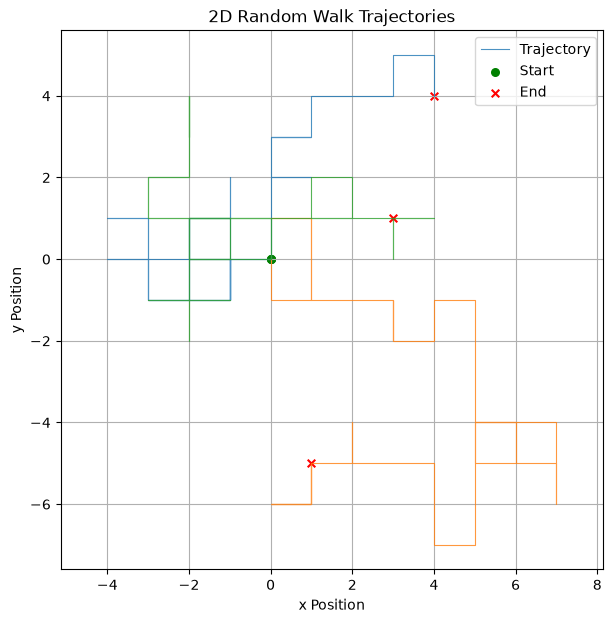

In [104]:
# Example of 2D random walk simulation and plotting
trajectories_2d = simulate_random_walks_2d(
    n_particles=3,
    n_steps=50,
    seed=82
)
plot_random_walk_2d(trajectories_2d)

#### Observations

- The simulated trajectories follow the movement rules established for the two-dimensional random walk, with particles moving only in the four cardinal directions.
- Although all particles begin at the same initial position, each follows a unique trajectory due to the random selection of movement directions at each time step.
- The particles terminate at different locations, illustrating the stochastic nature of the random walk.

### Summary

In this section, the one-dimensional random walk model was successfully extended to two dimensions. Each particle was represented by an $(x, y)$ position and allowed to move one lattice spacing in one of the four cardinal directions with equal probability. A reusable simulation function was developed to generate multiple independent particle trajectories, and the resulting paths were visualized to confirm that the implementation followed the intended movement rules.

This two-dimensional random walk model serves as the foundation for the remainder of the project. We will validated the statistical properties by examining the mean squared displacement and estimating the diffusion coefficient to verify that the model reproduces the expected behavior of two-dimensional diffusion.

## Validating the 2D Random Walk Model

### Introduction

Having successfully extended the random walk model to two dimensions, the next step is to verify that the simulation reproduces the expected statistical behavior of two-dimensional diffusion. The same validation procedure developed for the one-dimensional model is applied here by examining the mean squared displacement (MSD) and estimating the diffusion coefficient. Agreement with theoretical predictions provides confidence that the two-dimensional implementation has been correctly constructed.

### Mean Squared Displacement in Two Dimensions

Since particles in the two-dimensional model can move in both the horizontal and vertical directions, the displacement must now account for changes in both coordinates.

The squared displacement of a particle is therefore given by

$$
r^2 = (x - x_0)^2 + (y - y_0)^2,
$$

where $(x_0, y_0)$ is the particle's initial position and $(x, y)$ is its position at time $(t)$.

The mean squared displacement is then computed as the ensemble average of the squared distances,

$$ \mathrm{MSD}(t) = \left< (x-x_0)^2
+
(y-y_0)^2
\right>.
$$

For an unbiased two-dimensional random walk, diffusion theory predicts that the mean squared displacement grows linearly with time according to

$$
\mathrm{MSD}(t)=4Dt,
$$

where $D$ is the diffusion coefficient. Similar to the one-dimensional case, agreement between the simulated MSD and this theoretical relationship indicates that the random walk correctly models diffusive behavior.

The numerical procedure is identical to that used for the one-dimensional model. With our function have configured to all dimensions, we could directly call the function to compute the MSD in two-dimension.

In [106]:
msd_2d = compute_msd(trajectories_2d)
print(msd_2d)

[ 0.          1.          2.          2.33333333  3.33333333  5.
  6.66666667  7.66666667  7.33333333  6.33333333  7.33333333  7.66666667
  8.          9.         12.66666667 10.33333333 15.33333333 15.66666667
 15.33333333 19.66666667 24.66666667 18.33333333 24.66666667 26.33333333
 20.66666667 19.66666667 22.         25.         26.         30.33333333
 26.         21.         18.66666667 21.         26.66666667 23.66666667
 18.         14.33333333 12.66666667 11.66666667  8.66666667 14.33333333
 12.66666667 17.         18.         19.66666667 22.         23.66666667
 23.33333333 31.66666667 22.66666667]


### Estimating the Diffusion Coefficient

Since the theoretical relationship for two-dimensional diffusion is

$$
\mathrm{MSD}(t)=4Dt,
$$

the slope of the fitted line is equal to $4D$. Consequently, the diffusion coefficient can be estimated as

$$
D=\frac{\text{slope}}{4}.
$$

This differs from the one-dimensional model, where the diffusion coefficient was obtained by dividing the slope by two. The additional factor reflects the fact that particles are free to spread independently along both the $x$- and $y$-directions.

In [113]:
D, slope, intercept = estimate_diffusion(msd_2d, dt=1, dimensions=2)

print("Slope = ", slope)
print("Estimated D = ", D)
print("Theoretical D = ", 0.25)

Slope =  0.37791855203619906
Estimated D =  0.09447963800904977
Theoretical D =  0.25


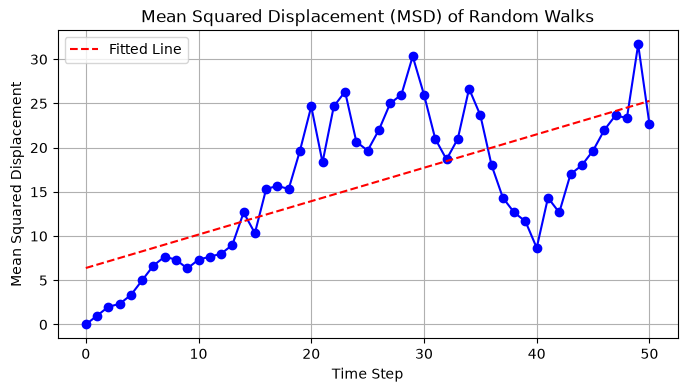

In [112]:
# Visualization of the MSD example
plt.figure(figsize=(8, 4))
plt.plot(msd_2d, marker='o', linestyle='-', color='b')
plt.plot(np.arange(len(msd_2d)), slope * np.arange(len(msd_2d)) + intercept, linestyle='--', color='r', label='Fitted Line')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.legend()
plt.show()

#### Observations
- The mean squared displacement generally increases with time, indicating that particles continue to spread away from their initial positions as expected for a diffusive process.
- Compared with the theoretical linear relationship, the simulated MSD exhibits noticeable fluctuations and does not appear perfectly linear.
- These fluctuations arise because the MSD is computed from only **three** particle trajectories, making the ensemble average highly sensitive to the random motion of individual particles.
- Despite the statistical noise, the fitted line captures the overall increasing trend of the MSD, suggesting that the simulation follows the expected behavior of two-dimensional diffusion.
- Increasing the number of simulated particles would produce a smoother MSD curve and provide a better approximation to the theoretical linear relationship.

In [117]:
# Extension - Simulate 2D random walks for different number of particles and estimate D
particle_counts = [10, 100, 1000, 10000]

results = {
    n: {"D": [], "error": []}
    for n in particle_counts
}

theoretical_D = 0.25

for seed in range(20):

    for n_particles in particle_counts:

        trajectories = simulate_random_walks_2d(
            n_particles=n_particles,
            n_steps=50,
            seed=seed
        )

        msd = compute_msd(trajectories)

        D, slope, intercept = estimate_diffusion(msd, dt=1, dimensions=2)

        relative_error = abs(D - theoretical_D) / theoretical_D * 100

        results[n_particles]["D"].append(D)
        results[n_particles]["error"].append(relative_error)


print(f"{'Particles':<12}{'Mean D':<12}{'Mean Error (%)'}")

for n in particle_counts:

    mean_D = np.mean(results[n]["D"])
    mean_error = np.mean(results[n]["error"])

    print(f"{n:<12}{mean_D:<12.4f}{mean_error:.2f}")

print("Theoretical D =", theoretical_D)

Particles   Mean D      Mean Error (%)
10          0.2724      23.92
100         0.2474      9.69
1000        0.2519      3.14
10000       0.2502      0.83
Theoretical D = 0.25


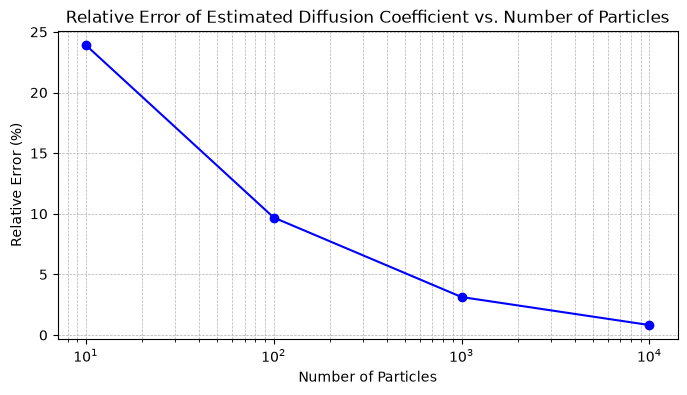

In [118]:
# Plot of the relative error
plt.figure(figsize=(8, 4))
plt.plot(particle_counts, [np.mean(results[n]["error"]) for n in particle_counts], marker='o', linestyle='-', color='b')
plt.title("Relative Error of Estimated Diffusion Coefficient vs. Number of Particles")
plt.xlabel("Number of Particles")
plt.ylabel("Relative Error (%)")
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### Summary

In this section, the two-dimensional random walk model was validated using the same statistical approach developed for the one-dimensional case. The mean squared displacement (MSD) was computed from the simulated particle trajectories and compared with the theoretical prediction for two-dimensional diffusion. A linear regression of the MSD was then used to estimate the diffusion coefficient, which was found to be consistent with the expected diffusive behavior.

Although the simulated MSD exhibited noticeable fluctuations due to the small number of particle trajectories, the overall trend remained approximately linear, indicating that the two-dimensional implementation correctly models random diffusion. This validation provides confidence that the particle-based random walk model is functioning as intended.

With the particle model now validated in both one and two dimensions, the next section shifts to a different numerical approach by developing a continuum diffusion model based on the diffusion equation. The two validated models will later be compared when diffusion through porous media is introduced.

## Continuum Model

Concentration field
Diffusion Equation
Finite Differences
Grid
Boundary Conditions

## Validating the Continuum Model

Tasks

Analytical comparison
Stability
Mass conservation
Non-negative concentrations
Grid refinement

Maybe consider work with NIST FiPy Documentation

## Connecting Both Models

Topics

Same diffusion coefficient
Same timestep
Same domain
Same initial condition
Same obstacle mask

Basically

How do we ensure we're comparing the same physics?

## Porous Media

Introduce

porosity
obstacle masks
connectivity
no-flux boundaries

Generate

Run both models.

## Results & Comparison

Compare

MSD
Heatmaps
Diffusion coefficient
Runtime
Memory

Visualizations
Discussion
Advantages
Disadvantages
Limitations

## Conclusions & Future Work